<a href="https://colab.research.google.com/github/indrajith-s-nair/Deep-Learning-Practise-/blob/main/practising_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt
#y=ax+b
# predetermined a and b
a=0.7
b=0.3
X=torch.arange(0,1,0.02).unsqueeze(1)
Y= (a * X) + b


In [ ]:
# SPLITTING  TO TEST DATA AND TRAINING DATA
Train_data_index=int(0.8*len(X))
X_train_data= X[:Train_data_index]
Y_train_data=Y[:Train_data_index]

X_test_data=X[Train_data_index:]
Y_test_data=Y[Train_data_index:]
print(len(X_train_data) ,len(Y_train_data),len(X_test_data), len(Y_test_data))
X_train_data, Y_train_data,X_test_data,Y_test_data



40 40 10 10


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800],
         [0.2000],
         [0.2200],
         [0.2400],
         [0.2600],
         [0.2800],
         [0.3000],
         [0.3200],
         [0.3400],
         [0.3600],
         [0.3800],
         [0.4000],
         [0.4200],
         [0.4400],
         [0.4600],
         [0.4800],
         [0.5000],
         [0.5200],
         [0.5400],
         [0.5600],
         [0.5800],
         [0.6000],
         [0.6200],
         [0.6400],
         [0.6600],
         [0.6800],
         [0.7000],
         [0.7200],
         [0.7400],
         [0.7600],
         [0.7800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260],
         [0.4400],
         [0.4540],
         [

In [ ]:

def Visualise(X_Neuro_Predicted,Y_Neuro_Predicted):
    plt.xlim(0, 1)
    plt.ylim(0,1)
    plt.scatter(X_train_data,Y_train_data,s=3,color="green",label="Train Data")
    plt.scatter(X_test_data,Y_test_data,s=3,color="blue",label="Test Data")
    if X_Neuro_Predicted != None or Y_Neuro_Predicted != None:
        plt.scatter(X_Neuro_Predicted,Y_Neuro_Predicted,s=3,color="red",label="Predicted Data")

    plt.legend()
    plt.show()



OMGGG Time for neural network   https://www.youtube.com/watch?v=Ilg3gGewQ5U

CREATING NEURAL NETWORK  SEEE https://docs.pytorch.org/docs/2.14/generated/torch.nn.Module.html#torch.nn.Module

In [ ]:
# Step 1 inherit
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.rand_a_value=nn.Parameter(torch.randn(1),requires_grad=True)
        self.rand_b_value=nn.Parameter(torch.randn(1),requires_grad=True)
    def forward(self,x):
            return (self.rand_a_value * x) + self.rand_b_value

In [ ]:
model0=LinearRegressionModel()
# SEE The thing before training
with torch.inference_mode():
    y=model0(X_test_data)
y

tensor([[1.4003],
        [1.4097],
        [1.4191],
        [1.4284],
        [1.4378],
        [1.4472],
        [1.4565],
        [1.4659],
        [1.4752],
        [1.4846]])

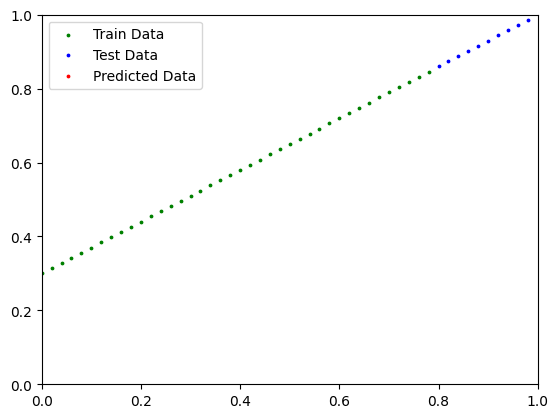

In [ ]:
Visualise(X_test_data,y)

In [ ]:
# Training Loop
def Training_Loop():
    epochs=110
    loss=torch.nn.L1Loss()
    my_optimization=torch.optim.SGD(model0.parameters(),lr=0.00001)
    for epoch in range(epochs):
        model0.train()
        y_train_pred=model0(X_train_data)
        output=loss(y_train_pred,Y_train_data)
        my_optimization.zero_grad()
        output.backward()
        my_optimization.step()




In [ ]:
Training_Loop()
print(model0.state_dict())

OrderedDict({'rand_a_value': tensor([0.7000]), 'rand_b_value': tensor([0.3000])})


In [ ]:
model0.eval()
with torch.inference_mode():
    Y_predicted=model0(X_test_data)
Y_predicted

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

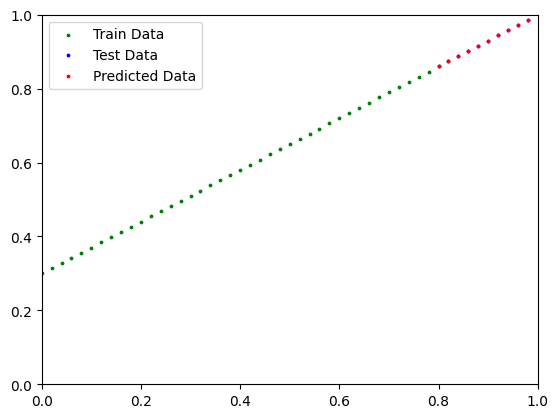

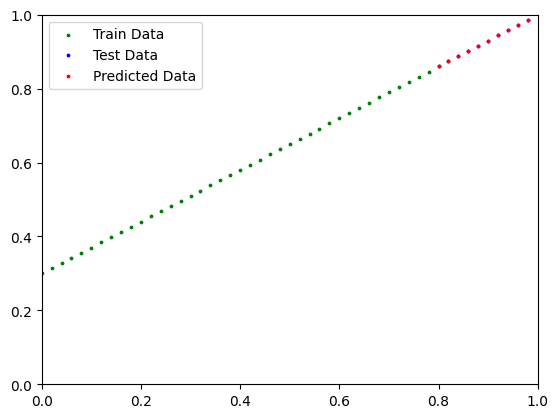

In [ ]:
Visualise(X_test_data,Y_predicted)